Generating synthetic atomic coordinates for HCM parity...

          RUNNING REFERENCE FRAMEWORK (SciPy)
-> SciPy HCM: 0.158748

          RUNNING DIMREDPY FRAMEWORK
-> DimRedPy HCM: 0.158748

          PARITY VALIDATION
MSE on Hausdorff Chirality Measure: 0.00e+00

SUCCESS: DimRedPy HCM perfectly matches SciPy exact reference.
Saved comparison plot to g:\mp\Decoding-Au-clusters\dimredpy_vs_others\dimredpy_vs_descriptors\verify_parity_descriptors_hcm_plot.png


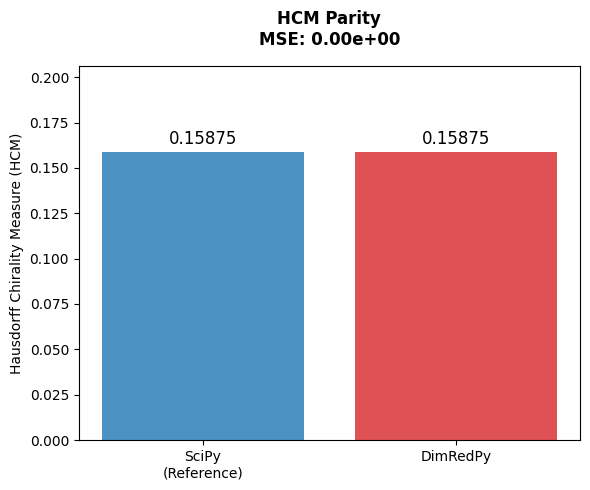

In [1]:
"""
Rigorous Verification of Descriptor Parity: Hausdorff Chirality Measure (HCM)
"""

import numpy as np
import os
import sys
import matplotlib.pyplot as plt
from scipy.spatial.distance import directed_hausdorff, pdist

# Robust path detection for repo root
script_dir = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
repo_root = os.path.abspath(os.path.join(script_dir, "..", ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

from dimredpy.shared.descriptors import hausdorff_chirality_measure

# ---------------------------------------------------------------------------
# 1. Generate Synthetic Data
# ---------------------------------------------------------------------------
print("Generating synthetic atomic coordinates for HCM parity...")
np.random.seed(42)
N_atoms = 100
# Generate a chiral-looking distribution (not perfectly symmetric)
positions = np.random.randn(N_atoms, 3) * [5.0, 3.0, 1.0]

# ---------------------------------------------------------------------------
# 2. Run Reference Framework (SciPy exact Hausdorff & pdist)
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING REFERENCE FRAMEWORK (SciPy)")
print("=======================================================")

# Exact reference implementation using scipy functions
cm = np.mean(positions, axis=0)
X = positions - cm
U, S, Vt = np.linalg.svd(X, full_matrices=False)
X_pca = X @ Vt.T

# Mirror image
X_mirror = X_pca.copy()
X_mirror[:, 2] *= -1

# SciPy directed_hausdorff returns (distance, index1, index2)
# We want the max of the two directed hausdorff distances
h1, _, _ = directed_hausdorff(X_pca, X_mirror)
h2, _, _ = directed_hausdorff(X_mirror, X_pca)
scipy_hausdorff = max(h1, h2)

# Scipy pdist for exact diameter
scipy_diameter = np.max(pdist(X_pca))

ref_hcm = scipy_hausdorff / scipy_diameter if scipy_diameter > 1e-10 else 0.0

print(f"-> SciPy HCM: {ref_hcm:.6f}")

# ---------------------------------------------------------------------------
# 3. Run DimRedPy Framework
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          RUNNING DIMREDPY FRAMEWORK")
print("=======================================================")

dimredpy_hcm = hausdorff_chirality_measure(positions)
print(f"-> DimRedPy HCM: {dimredpy_hcm:.6f}")

# ---------------------------------------------------------------------------
# 4. Parity Validation
# ---------------------------------------------------------------------------
print("\n=======================================================")
print("          PARITY VALIDATION")
print("=======================================================")

mse = (ref_hcm - dimredpy_hcm) ** 2

print(f"MSE on Hausdorff Chirality Measure: {mse:.2e}")

if mse < 1e-10:
    print("\nSUCCESS: DimRedPy HCM perfectly matches SciPy exact reference.")
else:
    print("\nFAILURE: Statistical divergence detected in HCM parity.")

# ---------------------------------------------------------------------------
# 5. Visual Verification
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(6, 5), facecolor='white')

bars = ax.bar(['SciPy\n(Reference)', 'DimRedPy'], [ref_hcm, dimredpy_hcm], color=['#1f77b4', '#d62728'], alpha=0.8)
ax.set_ylabel("Hausdorff Chirality Measure (HCM)")
ax.set_title(f"HCM Parity\nMSE: {mse:.2e}", fontweight='bold', pad=15)
ax.set_ylim(0, max(ref_hcm, dimredpy_hcm) * 1.3)

for bar in bars:
    height = bar.get_height()
    ax.annotate(f'{height:.5f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom', fontsize=12)

plt.tight_layout()
plot_path = os.path.join(script_dir, "verify_parity_descriptors_hcm_plot.png")
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
print(f"Saved comparison plot to {plot_path}")
